In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import __version__ as sklearn_version

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn_version)

pandas: 3.0.5
numpy: 2.4.6
scikit-learn: 1.9.0


In [2]:
import urllib.request
import zipfile

url = "https://archive.ics.uci.edu/static/public/350/default+of+credit+card+clients.zip"
zip_path = "credit_data.zip"

urllib.request.urlretrieve(url, zip_path)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(".")
    print(z.namelist())

['default of credit card clients.xls']


In [3]:
df = pd.read_excel("default of credit card clients.xls", header=1)
print(df.shape)
df.head()

(30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## EDA

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_AMT3        

In [5]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [6]:
df['default payment next month'].value_counts()
df['default payment next month'].value_counts(normalize=True)

default payment next month
0    0.7788
1    0.2212
Name: proportion, dtype: float64

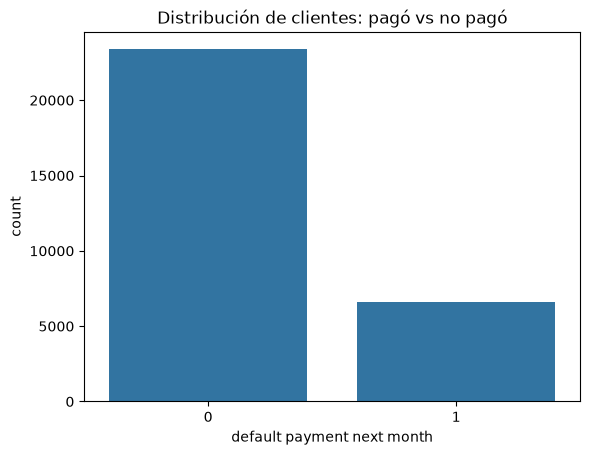

In [7]:
sns.countplot(data=df, x='default payment next month')
plt.title('Distribución de clientes: pagó vs no pagó')
plt.show()

In [8]:
# existe deesbalance de clases

In [10]:
df['EDUCATION'].value_counts()

EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64

In [11]:
df['MARRIAGE'].value_counts()

MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64

In [12]:
df = df.drop(columns=['ID'])

In [13]:
# EDUCATION: 0, 5, 6 no están documentados así que nos mandamos a 4 (otros)
df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
# MARRIAGE: 0 no está documentado, lo mandamos a 3 (otro)
df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})
print(df['EDUCATION'].value_counts())
print(df['MARRIAGE'].value_counts())

EDUCATION
2    14030
1    10585
3     4917
4      468
Name: count, dtype: int64
MARRIAGE
2    15964
1    13659
3      377
Name: count, dtype: int64


In [14]:
df.duplicated().sum()

np.int64(35)

In [15]:
df = df.drop_duplicates()
print(df.shape)

(29965, 24)


In [16]:
X = df.drop(columns=['default payment next month'])
y = df['default payment next month']
categorical_cols = ['SEX', 'EDUCATION', 'MARRIAGE']
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print(X.shape, y.shape)

(29965, 26) (29965,)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=123,
    stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(23972, 26) (5993, 26)
default payment next month
0    0.778742
1    0.221258
Name: proportion, dtype: float64
default payment next month
0    0.778742
1    0.221258
Name: proportion, dtype: float64


In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled = scaler.transform(X_test)    

print(X_train_scaled.shape, X_test_scaled.shape)

(23972, 26) (5993, 26)


### Baseline: regresión logística

In [20]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=123, max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

In [21]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8088


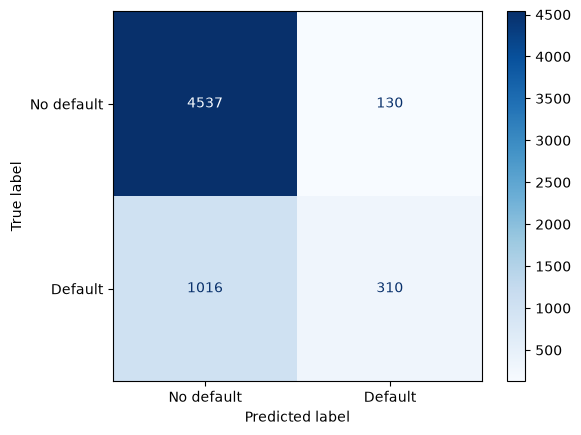

In [34]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, ConfusionMatrixDisplay

matrix = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=['No default', 'Default']).plot(cmap='Blues')
plt.show()

In [23]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4667
           1       0.70      0.23      0.35      1326

    accuracy                           0.81      5993
   macro avg       0.76      0.60      0.62      5993
weighted avg       0.79      0.81      0.77      5993



In [24]:
y_proba = model.predict_proba(X_test_scaled)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.7269


La regresión logística aprendió que la apuesta más segura para minimizar error total es decir "sí va a pagar" casi siempre, porque el 78% de las veces acierta con eso. Es un sesgo del desbalance de clases, hay que mejorar el modelo

In [26]:
model_balanced = LogisticRegression(random_state=123, max_iter=1000, class_weight='balanced')
model_balanced.fit(X_train_scaled, y_train)

y_pred_balanced = model_balanced.predict(X_test_scaled)
y_proba_balanced = model_balanced.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_balanced))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_balanced):.4f}")

              precision    recall  f1-score   support

           0       0.87      0.71      0.78      4667
           1       0.38      0.64      0.48      1326

    accuracy                           0.69      5993
   macro avg       0.63      0.67      0.63      5993
weighted avg       0.77      0.69      0.71      5993

ROC-AUC: 0.7276


Recall de clase 1: pasa de 0.23 a 0.64. Se detectan casi 3 veces más clientes que realmente no van a pagar.

Precision de clase 1: pasa de 0.70 a 0.38. De cada 10 clientes que marca como "riesgo", solo 4 realmente lo eran. Se niega crédito a más gente buena por error.

ROC-AUC: pasa de 0.7269 a 0.7276. Casi idéntico, confirmando que el modelo no aprendió a separar mejor las clases solo movimos dónde trazamos la línea de decisión

## Random Forest

In [27]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=123,
    class_weight='balanced',
    max_depth=10
)
rf_model.fit(X_train, y_train)  # los árboles no necesitan datos escalados

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")

              precision    recall  f1-score   support

           0       0.88      0.84      0.86      4667
           1       0.51      0.59      0.55      1326

    accuracy                           0.78      5993
   macro avg       0.69      0.71      0.70      5993
weighted avg       0.80      0.78      0.79      5993

ROC-AUC: 0.7793


In [28]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [5, 8, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=123, class_weight='balanced'),
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=cv,
    random_state=123,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print("Mejores hiperparámetros:", random_search.best_params_)
print("Mejor ROC-AUC (validación cruzada):", random_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Mejores hiperparámetros: {'n_estimators': 400, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 15}
Mejor ROC-AUC (validación cruzada): 0.7801559737640185


In [29]:
best_rf = random_search.best_estimator_

y_pred_best = best_rf.predict(X_test)
y_proba_best = best_rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_best))
print(f"ROC-AUC (test): {roc_auc_score(y_test, y_proba_best):.4f}")

              precision    recall  f1-score   support

           0       0.88      0.85      0.86      4667
           1       0.53      0.59      0.56      1326

    accuracy                           0.79      5993
   macro avg       0.70      0.72      0.71      5993
weighted avg       0.80      0.79      0.80      5993

ROC-AUC (test): 0.7809


In [30]:
from sklearn.ensemble import HistGradientBoostingClassifier

gb_model = HistGradientBoostingClassifier(
    random_state=123,
    max_iter=300,
    max_depth=6,
    learning_rate=0.05,
    class_weight='balanced'
)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
y_proba_gb = gb_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_gb))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_gb):.4f}")

              precision    recall  f1-score   support

           0       0.88      0.81      0.85      4667
           1       0.48      0.62      0.54      1326

    accuracy                           0.77      5993
   macro avg       0.68      0.72      0.69      5993
weighted avg       0.79      0.77      0.78      5993

ROC-AUC: 0.7840


Aqui con clusiones, qué modelo desicidimos? 

In [32]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    gb_model, X_test, y_test,
    n_repeats=10,
    random_state=123,
    scoring='roc_auc'
)

importances_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

print(importances_df.head(15))

        feature  importance_mean  importance_std
2         PAY_0         0.076113        0.004634
8     BILL_AMT1         0.019708        0.002165
0     LIMIT_BAL         0.017599        0.003012
16     PAY_AMT3         0.010434        0.001634
3         PAY_2         0.009831        0.001239
4         PAY_3         0.005574        0.001397
15     PAY_AMT2         0.004745        0.001667
14     PAY_AMT1         0.004740        0.001457
7         PAY_6         0.003423        0.001163
23  EDUCATION_4         0.003167        0.000903
19     PAY_AMT6         0.002955        0.000964
9     BILL_AMT2         0.002426        0.000621
5         PAY_4         0.002422        0.000849
17     PAY_AMT4         0.002379        0.000805
13    BILL_AMT6         0.001877        0.000815


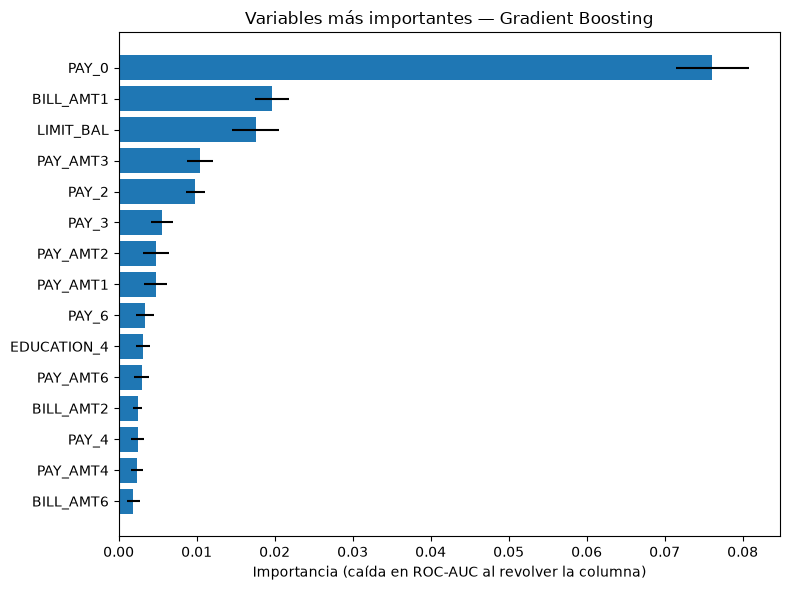

In [33]:
top_features = importances_df.head(15)

plt.figure(figsize=(8, 6))
plt.barh(top_features['feature'], top_features['importance_mean'], xerr=top_features['importance_std'])
plt.gca().invert_yaxis()
plt.xlabel('Importancia (caída en ROC-AUC al revolver la columna)')
plt.title('Variables más importantes — Gradient Boosting')
plt.tight_layout()
plt.show()

## Conclusiones

Este proyecto tuvo como objetivo predecir si un cliente cumplirá o no con el pago de su crédito, utilizando el dataset "Default of Credit Card Clients" del UCI Machine Learning Repository, con información de 30,000 clientes de un banco en Taiwán.

Durante el análisis exploratorio se identificó que el conjunto de datos presenta un desbalance de clases considerable, ya que aproximadamente el 78% de los clientes cumplió con su pago mientras que el 22% restante incurrió en incumplimiento. También se detectaron categorías no documentadas en las variables EDUCATION y MARRIAGE, así como 35 registros duplicados, los cuales fueron tratados antes del modelado.

Se entrenaron y compararon tres enfoques de clasificación. La regresión logística obtuvo un ROC AUC de 0.727 y un recall de apenas 0.23 para la clase de incumplimiento, lo cual evidenció que el desbalance de clases sesgaba las predicciones hacia la categoría mayoritaria. Al incorporar ponderación de clases el recall mejoró a 0.64, aunque con una reducción notable en precisión. Posteriormente se evaluó un modelo de Random Forest, el cual elevó el ROC AUC a 0.779 sin necesidad de sacrificar tanta precisión, y tras un proceso de optimización de hiperparámetros mediante validación cruzada alcanzó un ROC AUC de 0.781. Finalmente, un modelo de Gradient Boosting logró el mejor desempeño general, con un ROC AUC de 0.784 y un recall de 0.62 para la clase de interés, por lo que fue seleccionado como modelo final.

El análisis de importancia de variables mediante permutation importance mostró que el historial de pago más reciente, representado por la variable PAY_0, es el predictor más relevante, seguido del monto de la factura más reciente y del límite de crédito otorgado. Estos resultados son consistentes con criterios utilizados habitualmente en el análisis de riesgo crediticio, lo que otorga interpretabilidad y respaldo práctico al modelo obtenido.

A pesar de los resultados favorables, el modelo aún no identifica a un porcentaje importante de los clientes que efectivamente incurren en incumplimiento, por lo que no debería implementarse en un entorno real sin un análisis adicional del costo asociado a cada tipo de error. Asimismo, se observó que tanto el ajuste de hiperparámetros como el cambio de algoritmo produjeron mejoras marginales una vez superado cierto umbral, lo que sugiere que el techo de desempeño actual está limitado por la información disponible más que por la técnica de modelado empleada.

## Próximos pasos

Como continuación de este trabajo se proponen las siguientes líneas de mejora.

1. Desarrollar nuevas variables a partir del historial de pagos, como la cantidad de meses con atraso en el periodo analizado o la tendencia de la deuda a lo largo del tiempo.
2. Ajustar el umbral de decisión del modelo con base en el costo real de negocio de aprobar créditos a clientes que incumplirán frente al costo de rechazar créditos a clientes que sí habrían pagado.
3. Evaluar técnicas de sobremuestreo como SMOTE como alternativa al ajuste de pesos por clase.
4. Validar el desempeño del modelo con datos más recientes, dado que los patrones de comportamiento crediticio evolucionan con el tiempo.